# Part 2 — Retrieval Baselines for Hinglish RAG (RQ1)

**Question this notebook answers:** how do *sparse (BM25)*, *dense*, and *hybrid (RRF / weighted)* retrieval behave when a query is in English, Devanagari Hindi, or Romanized Hinglish, and the evidence collection is parallel Hindi + English Wikipedia?

**What changed from the earlier notebook**
- Passages have IDs; gold labels are passage IDs, so the relevant text really exists in the corpus
- Real BM25 (`rank_bm25`) with a tokenizer that does **not** break Devanagari words at vowel signs
- Separate sparse-only, dense-only, RRF and weighted-fusion rows (the three retrievers RQ1 compares)
- Recall@k, Hit@k, MRR@10, nDCG@10 averaged over many queries, split by query type and Hinglish spelling variant
- Alpha sweep (dense weight 0 to 1) with min-max score normalization
- Latency recorded for every query
- A `TRANSFORMS` hook so Part 3 (transliteration / LLM rewriting) can plug in without touching this code
- Optional cross-encoder re-ranker (off by default)

**Workflow:** run top to bottom. Fill `data/queries.csv` (a seed file is created for you), re-run from the "Load queries" cell.

In [ ]:
# 0. Install dependencies (run once in a fresh Colab / runtime)
%pip install -q rank-bm25 sentence-transformers wikipedia-api pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 721.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 4.3 MB/s eta 0:00:00


In [ ]:
# 1. Imports and configuration
import os, re, json, time, random
import numpy as np
import pandas as pd

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

PASSAGES_FILE = f"{DATA_DIR}/passages.jsonl"
QUERIES_FILE = f"{DATA_DIR}/queries.csv"

REBUILD_CORPUS = False          # True = re-download Wikipedia passages
MODEL_NAME = "BAAI/bge-m3"      # lighter option: "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_SEQ_LEN = 512
USE_RERANKER = False            # optional cross-encoder re-ranking (extra method row)
RERANKER_NAME = "BAAI/bge-reranker-v2-m3"

KS = (1, 3, 5, 10)              # cut-offs for Recall@k / Hit@k
CANDIDATE_DEPTH = 100           # how deep each retriever's ranking goes before fusion
RRF_K = 60
ALPHA_DEFAULT = 0.5             # dense weight for weighted fusion
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# state label -> English Wikipedia title (the Hindi page is found through the language link)
STATES = {
    "Rajasthan": "Rajasthan",
    "Maharashtra": "Maharashtra",
    "Gujarat": "Gujarat",
    "Kerala": "Kerala",
    "Bihar": "Bihar",
    "Uttar Pradesh": "Uttar Pradesh",
    "Tamil Nadu": "Tamil Nadu",
    "West Bengal": "West Bengal",
    "Karnataka": "Karnataka",
    "Punjab": "Punjab, India",
    "Madhya Pradesh": "Madhya Pradesh",
    "Odisha": "Odisha",
}
CHUNK_WORDS, CHUNK_OVERLAP, MAX_CHUNKS_PER_ARTICLE = 120, 20, 15
print("Config loaded.")

Config loaded.


## 2. Corpus — parallel Hindi / English Wikipedia passages
Each Indian-state article is fetched in English and, through its language link, in Hindi, then split into overlapping ~120-word passages. Every passage gets an ID like `Rajasthan|hi|3`, so gold labels can be matched by ID, not by exact text.

In [ ]:
def clean_wiki_text(text):
    text = re.sub(r"={2,}", " ", text)           # section markers
    return re.sub(r"\s+", " ", text).strip()

def chunk_text(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP, max_chunks=MAX_CHUNKS_PER_ARTICLE):
    words = text.split()
    step = size - overlap
    chunks = []
    for start in range(0, len(words), step):
        piece = words[start:start + size]
        if len(piece) < 30:
            break
        chunks.append(" ".join(piece))
        if len(chunks) >= max_chunks:
            break
    return chunks

def build_corpus():
    import wikipediaapi
    en = wikipediaapi.Wikipedia(user_agent="HinglishRAGResearch/1.0", language="en")
    records = []
    for state, title in STATES.items():
        en_page = en.page(title)
        if not en_page.exists():
            print(f"  [skip] no English page for {title}")
            continue
        hi_page = en_page.langlinks.get("hi")
        for lang, page in (("en", en_page), ("hi", hi_page)):
            if page is None:
                print(f"  [warn] no Hindi page for {state}")
                continue
            for i, ch in enumerate(chunk_text(clean_wiki_text(page.text))):
                records.append({"pid": f"{state}|{lang}|{i}", "state": state, "lang": lang, "text": ch})
        print(f"  {state}: done")
    with open(PASSAGES_FILE, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"Saved {len(records)} passages to {PASSAGES_FILE}")

if REBUILD_CORPUS or not os.path.exists(PASSAGES_FILE):
    build_corpus()
else:
    print(f"{PASSAGES_FILE} exists; skipping download (set REBUILD_CORPUS = True to refresh).")

passages = pd.read_json(PASSAGES_FILE, lines=True, encoding="utf-8")
print(passages.groupby("lang").size().to_string())
PID_TO_LANG = dict(zip(passages.pid, passages.lang))

  Rajasthan: done
  Maharashtra: done
  Gujarat: done
  Kerala: done
  Bihar: done
  Uttar Pradesh: done
  Tamil Nadu: done
  West Bengal: done
  Karnataka: done
  Punjab: done
  Madhya Pradesh: done
  Odisha: done
Saved 344 passages to data/passages.jsonl
lang
en    180
hi    164


## 3. Queries and gold labels
`data/queries.csv` columns: `qid, group_id, lang_type, variant, state, query, answer_en, answer_hi`

- One **group** = one question asked in four ways: English (`en`), Devanagari Hindi (`hi`), and several Romanized spellings (`hinglish`, variants `v1, v2, v3`).
- **Gold passages** = passages from that state's article (either language) that contain `answer_en` (English passages) or `answer_hi` (Hindi passages). So you label by writing the answer string, not by hunting passage IDs.
- A seed file with 6 groups is created if none exists. **Extend it to 50+ groups** (fact types: capital, language, river, festival, area, founding date, and so on).

In [ ]:
SEEDS = [
    # state, answer_en, answer_hi, english, hindi, [hinglish spellings]
    ("Rajasthan", "Jaipur", "जयपुर", "What is the capital of Rajasthan?", "राजस्थान की राजधानी क्या है?",
     ["Rajasthan ki rajdhani kya hai?", "Rajasthan ki raajdhaani kya hai", "rajasthan ki rajdhaani kya he"]),
    ("Maharashtra", "Mumbai", "मुंबई", "What is the capital of Maharashtra?", "महाराष्ट्र की राजधानी क्या है?",
     ["Maharashtra ki rajdhani kya hai?", "Maharashtra ki raajdhaani kya hai", "maharashtra ki rajdhani kya he"]),
    ("Bihar", "Patna", "पटना", "What is the capital of Bihar?", "बिहार की राजधानी क्या है?",
     ["Bihar ki rajdhani kya hai?", "Bihar ki raajdhaani kya hai", "bihar ki rajdhani kya he"]),
    ("Gujarat", "Gandhinagar", "गांधीनगर", "What is the capital of Gujarat?", "गुजरात की राजधानी क्या है?",
     ["Gujarat ki rajdhani kya hai?", "Gujarat ki raajdhaani kya hai", "gujarat ki rajdhani kya he"]),
    ("Uttar Pradesh", "Lucknow", "लखनऊ", "What is the capital of Uttar Pradesh?", "उत्तर प्रदेश की राजधानी क्या है?",
     ["Uttar Pradesh ki rajdhani kya hai?", "Uttar Pradesh ki raajdhaani kya hai", "uttar pradesh ki rajdhani kya he"]),
    ("Kerala", "Thiruvananthapuram", "तिरुवनंतपुरम", "What is the capital of Kerala?", "केरल की राजधानी क्या है?",
     ["Kerala ki rajdhani kya hai?", "Kerala ki raajdhaani kya hai", "kerala ki rajdhani kya he"]),
]

def write_seed_queries(path):
    rows = []
    for g, (state, a_en, a_hi, q_en, q_hi, hing) in enumerate(SEEDS, 1):
        gid = f"g{g:02d}"
        base = dict(group_id=gid, state=state, answer_en=a_en, answer_hi=a_hi)
        rows.append(dict(base, qid=f"{gid}_en", lang_type="en", variant="", query=q_en))
        rows.append(dict(base, qid=f"{gid}_hi", lang_type="hi", variant="", query=q_hi))
        for v, q in enumerate(hing, 1):
            rows.append(dict(base, qid=f"{gid}_hing{v}", lang_type="hinglish", variant=f"v{v}", query=q))
    cols = ["qid", "group_id", "lang_type", "variant", "state", "query", "answer_en", "answer_hi"]
    pd.DataFrame(rows)[cols].to_csv(path, index=False, encoding="utf-8")
    print(f"Seed file written to {path} ({len(rows)} queries). Extend it, then re-run from this cell.")

if not os.path.exists(QUERIES_FILE):
    write_seed_queries(QUERIES_FILE)

queries = pd.read_csv(QUERIES_FILE, encoding="utf-8").fillna("")
print(queries.groupby("lang_type").size().to_string())

Seed file written to data/queries.csv (30 queries). Extend it, then re-run from this cell.
lang_type
en           6
hi           6
hinglish    18


In [ ]:
# Build gold sets and check them
def build_gold(queries, passages):
    gold = {}
    for r in queries.itertuples():
        sub = passages[passages.state == r.state]
        ids = set()
        if r.answer_en:
            m = sub[(sub.lang == "en") & sub.text.str.contains(str(r.answer_en), case=False, regex=False)]
            ids |= set(m.pid)
        if r.answer_hi:
            m = sub[(sub.lang == "hi") & sub.text.str.contains(str(r.answer_hi), regex=False)]
            ids |= set(m.pid)
        gold[r.qid] = ids
    return gold

gold = build_gold(queries, passages)
n_gold = pd.Series({q: len(g) for q, g in gold.items()})
print(f"Queries with at least one gold passage: {(n_gold > 0).sum()} / {len(n_gold)}")
print(f"Mean gold passages per query: {n_gold[n_gold > 0].mean():.1f}")

bad_groups = sorted(set(queries.loc[queries.qid.isin(n_gold[n_gold == 0].index), "group_id"]))
if bad_groups:
    print("\nNo gold passage found for groups:", bad_groups)
    print("Fix the answer_en / answer_hi spelling (check how the article actually writes it), or the state name.")

eval_queries = queries[queries.qid.map(lambda q: len(gold[q]) > 0)].reset_index(drop=True)
print(f"\nEvaluating on {len(eval_queries)} queries.")

Queries with at least one gold passage: 30 / 30
Mean gold passages per query: 5.2

Evaluating on 30 queries.


## 4. Retrievers
**Tokenizer for BM25.** Python's plain `\w` splits Devanagari words at vowel signs (`भारत` becomes `भ`, `रत`). The pattern below keeps the Hindi combining marks inside the word and drops the danda `।`.

In [ ]:
from rank_bm25 import BM25Okapi

TOKEN_RE = re.compile(r"[\w\u0900-\u0963\u0966-\u097F]+")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

# sanity check: Hindi words must stay whole
assert tokenize("भारत की राजधानी।") == ["भारत", "की", "राजधानी"], tokenize("भारत की राजधानी।")

bm25 = BM25Okapi([tokenize(t) for t in passages.text])
pids = passages.pid.to_numpy()

def sparse_scores(q):
    return np.asarray(bm25.get_scores(tokenize(q)), dtype=float)
print("BM25 index ready:", len(pids), "passages")

BM25 index ready: 344 passages


In [8]:
from sentence_transformers import SentenceTransformer

print("Loading", MODEL_NAME)
model = SentenceTransformer(MODEL_NAME)
model.max_seq_length = MAX_SEQ_LEN

emb_path = f"{DATA_DIR}/emb_{MODEL_NAME.split('/')[-1]}.npy"
corpus_emb = None
if os.path.exists(emb_path):
    cached = np.load(emb_path)
    if cached.shape[0] == len(passages):
        corpus_emb = cached
        print("Loaded cached embeddings:", corpus_emb.shape)
if corpus_emb is None:
    corpus_emb = model.encode(passages.text.tolist(), batch_size=16, show_progress_bar=True,
                              normalize_embeddings=True, convert_to_numpy=True)
    np.save(emb_path, corpus_emb)
    print("Encoded and cached:", corpus_emb.shape)

def dense_scores(q):
    v = model.encode([q], normalize_embeddings=True, convert_to_numpy=True)[0]
    return corpus_emb @ v          # cosine similarity (both sides normalized)

Loading BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loaded cached embeddings: (344, 1024)


In [9]:
# Ranking and fusion helpers
def top_ids(scores, n=CANDIDATE_DEPTH, drop_nonpositive=False):
    order = np.argsort(-scores, kind="stable")[:n]
    if drop_nonpositive:
        order = [i for i in order if scores[i] > 0]   # BM25: zero overlap = not retrieved
    return [pids[i] for i in order]

def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else np.zeros_like(s)

def rrf_fuse(rank_lists, k=RRF_K):
    fused = {}
    for ranks in rank_lists:
        for r, pid in enumerate(ranks, 1):
            fused[pid] = fused.get(pid, 0.0) + 1.0 / (k + r)
    return [p for p, _ in sorted(fused.items(), key=lambda x: -x[1])]

def weighted_fuse(s_sparse, s_dense, alpha):
    return top_ids(alpha * minmax(s_dense) + (1 - alpha) * minmax(s_sparse))

# Each method takes a query string and returns a ranked list of passage IDs
def run_sparse(q):
    return top_ids(sparse_scores(q), drop_nonpositive=True)

def run_dense(q):
    return top_ids(dense_scores(q))

def run_rrf(q):
    return rrf_fuse([top_ids(sparse_scores(q), drop_nonpositive=True), top_ids(dense_scores(q))])

def run_weighted(q, alpha=ALPHA_DEFAULT):
    return weighted_fuse(sparse_scores(q), dense_scores(q), alpha)

METHODS = {
    "bm25 (sparse)": run_sparse,
    "dense": run_dense,
    "hybrid RRF": run_rrf,
    f"hybrid weighted (alpha={ALPHA_DEFAULT})": run_weighted,
}

if USE_RERANKER:
    from sentence_transformers import CrossEncoder
    reranker = CrossEncoder(RERANKER_NAME, max_length=512)
    pid_to_text = dict(zip(passages.pid, passages.text))
    def run_rrf_rerank(q, depth=20):
        cand = run_rrf(q)[:depth]
        scores = reranker.predict([(q, pid_to_text[p]) for p in cand])
        return [cand[i] for i in np.argsort(-scores)]
    METHODS["hybrid RRF + cross-encoder"] = run_rrf_rerank
print("Methods:", list(METHODS))

Methods: ['bm25 (sparse)', 'dense', 'hybrid RRF', 'hybrid weighted (alpha=0.5)']


## 5. Metrics and evaluation loop
- **Hit@k**: did at least one gold passage appear in the top k? (main headline number)
- **Recall@k**: fraction of all gold passages found in the top k (can look low when many passages mention the answer)
- **MRR@10** and **nDCG@10**: rank-aware quality
- **latency_ms**: query transform + retrieval time per query (includes query encoding)
- **top1_lang**: language of the top-ranked passage, to see which side of the collection Hinglish queries land on

In [10]:
def metrics_for(ranked, gold_set):
    out = {}
    for k in KS:
        hits = len(set(ranked[:k]) & gold_set)
        out[f"hit@{k}"] = float(hits > 0)
        out[f"recall@{k}"] = hits / len(gold_set)
    out["mrr@10"] = next((1.0 / i for i, p in enumerate(ranked[:10], 1) if p in gold_set), 0.0)
    dcg = sum(1.0 / np.log2(i + 1) for i, p in enumerate(ranked[:10], 1) if p in gold_set)
    ideal = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(gold_set), 10) + 1))
    out["ndcg@10"] = dcg / ideal
    return out

# Hook for Part 3: add ("name", function) pairs, e.g. phonetic transliteration or LLM rewriting
TRANSFORMS = {
    "none": lambda q: q,
}

def evaluate(method_name, method_fn, transform_name="none"):
    transform_fn = TRANSFORMS[transform_name]
    rows = []
    for r in eval_queries.itertuples():
        t0 = time.perf_counter()
        q = transform_fn(r.query)
        ranked = method_fn(q)
        ms = (time.perf_counter() - t0) * 1000
        row = {"method": method_name, "transform": transform_name, "qid": r.qid, "group_id": r.group_id,
               "lang_type": r.lang_type, "variant": r.variant, "latency_ms": ms,
               "top1_lang": PID_TO_LANG.get(ranked[0]) if ranked else "none"}
        row.update(metrics_for(ranked, gold[r.qid]))
        rows.append(row)
    return pd.DataFrame(rows)

# warm-up so model load time is not counted in latency
_ = run_dense("warm up")

In [11]:
all_results = []
for t_name in TRANSFORMS:
    for m_name, m_fn in METHODS.items():
        print(f"Running: {m_name} | transform={t_name}")
        all_results.append(evaluate(m_name, m_fn, t_name))
results = pd.concat(all_results, ignore_index=True)
results.to_csv(f"{RESULTS_DIR}/per_query_results.csv", index=False, encoding="utf-8")
print("Done:", len(results), "rows")

Running: bm25 (sparse) | transform=none
Running: dense | transform=none
Running: hybrid RRF | transform=none
Running: hybrid weighted (alpha=0.5) | transform=none
Done: 120 rows


## 6. Results

In [12]:
metric_cols = [f"hit@{k}" for k in KS] + [f"recall@{k}" for k in KS] + ["mrr@10", "ndcg@10", "latency_ms"]
summary = (results.groupby(["transform", "method", "lang_type"])[metric_cols].mean().round(3))
summary.to_csv(f"{RESULTS_DIR}/summary_by_method_and_language.csv", encoding="utf-8")

print("nDCG@10 (rows = method, columns = query type)")
display(results.pivot_table(index=["transform", "method"], columns="lang_type", values="ndcg@10").round(3))
print("Hit@5")
display(results.pivot_table(index=["transform", "method"], columns="lang_type", values="hit@5").round(3))
print("Mean latency (ms)")
display(results.pivot_table(index=["transform", "method"], columns="lang_type", values="latency_ms").round(1))

nDCG@10 (rows = method, columns = query type)


lang_type                                 en     hi  hinglish
transform method                                             
none      bm25 (sparse)                0.367  0.373     0.208
          dense                        0.768  0.696     0.543
          hybrid RRF                   0.519  0.445     0.429
          hybrid weighted (alpha=0.5)  0.522  0.441     0.453

Hit@5


lang_type                                 en     hi  hinglish
transform method                                             
none      bm25 (sparse)                0.833  0.833     0.556
          dense                        1.000  1.000     1.000
          hybrid RRF                   0.833  0.833     0.833
          hybrid weighted (alpha=0.5)  0.833  0.833     0.889

Mean latency (ms)


lang_type                                 en     hi  hinglish
transform method                                             
none      bm25 (sparse)                  4.5    2.9       3.8
          dense                        709.0  698.2     939.0
          hybrid RRF                   563.7  532.3     514.6
          hybrid weighted (alpha=0.5)  377.6  352.9     374.3

In [13]:
# Hinglish spelling variants: does the spelling change the score?
hing = results[results.lang_type == "hinglish"]
display(hing.pivot_table(index=["method"], columns="variant", values="ndcg@10").round(3))

# Which language collection does the top-1 passage come from?
display(pd.crosstab([results.method, results.lang_type], results.top1_lang, normalize="index").round(2))

variant,v1,v2,v3
method,,,
bm25 (sparse),0.227,0.227,0.170
dense,0.621,0.585,0.423
hybrid RRF,0.441,0.381,0.465
hybrid weighted (alpha=0.5),0.475,0.436,0.448


top1_lang                                en    hi
method                      lang_type            
bm25 (sparse)               en         1.00  0.00
                            hi         0.00  1.00
                            hinglish   1.00  0.00
dense                       en         0.83  0.17
                            hi         0.00  1.00
                            hinglish   1.00  0.00
hybrid RRF                  en         1.00  0.00
                            hi         0.00  1.00
                            hinglish   1.00  0.00
hybrid weighted (alpha=0.5) en         1.00  0.00
                            hi         0.00  1.00
                            hinglish   1.00  0.00

## 7. Dense-weight sweep (alpha)
Min-max normalization is applied to the sparse and dense scores before mixing. `alpha = 0` is BM25 only, `alpha = 1` is dense only. This shows how sensitive hybrid retrieval is to the weighting when the sparse side collapses on Romanized queries.

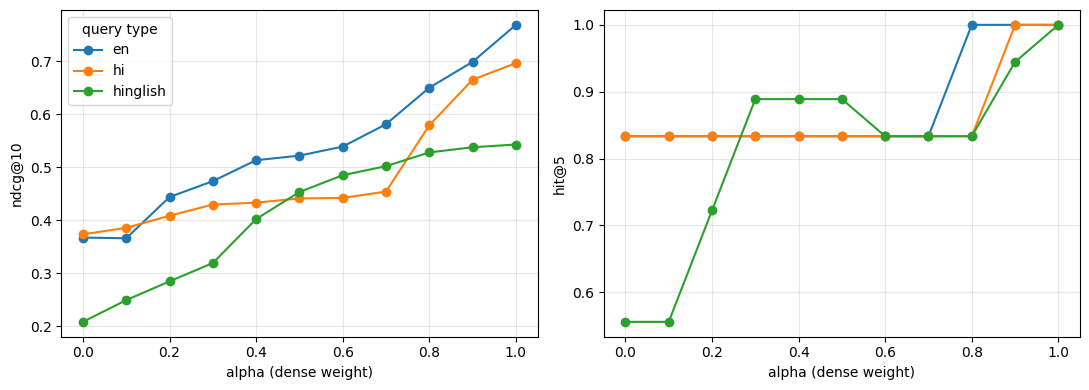

In [14]:
import matplotlib
import matplotlib.pyplot as plt

ALPHAS = np.round(np.arange(0, 1.01, 0.1), 2)
score_cache = {r.qid: (sparse_scores(r.query), dense_scores(r.query)) for r in eval_queries.itertuples()}

sweep_rows = []
for r in eval_queries.itertuples():
    s_sp, s_de = score_cache[r.qid]
    for a in ALPHAS:
        m = metrics_for(weighted_fuse(s_sp, s_de, a), gold[r.qid])
        sweep_rows.append({"alpha": a, "lang_type": r.lang_type, "ndcg@10": m["ndcg@10"], "hit@5": m["hit@5"]})
sweep = pd.DataFrame(sweep_rows).groupby(["lang_type", "alpha"]).mean().reset_index()
sweep.to_csv(f"{RESULTS_DIR}/alpha_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["ndcg@10", "hit@5"]):
    for lt, g in sweep.groupby("lang_type"):
        ax.plot(g.alpha, g[metric], marker="o", label=lt)
    ax.set_xlabel("alpha (dense weight)"); ax.set_ylabel(metric); ax.grid(alpha=.3)
axes[0].legend(title="query type")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/alpha_sweep.png", dpi=200)
plt.show()

## 8. Tokenization check (RQ1 mechanism)
How many subword tokens does the dense model's tokenizer use for each query type? If Romanized spellings fragment more, that supports the tokenization argument in the introduction.

In [15]:
tok = model.tokenizer
frag = eval_queries.copy()
frag["n_tokens"] = frag["query"].map(lambda q: len(tok.tokenize(q)))
frag["n_words"] = frag["query"].map(lambda q: len(q.split()))
frag["tokens_per_word"] = (frag.n_tokens / frag.n_words).round(2)
display(frag.groupby(["lang_type", "variant"])[["n_tokens", "tokens_per_word"]].mean().round(2))

ex = frag[frag.group_id == frag.group_id.iloc[0]][["lang_type", "variant", "query"]]
for r in ex.itertuples():
    print(f"{r.lang_type:9s} {r.variant:3s} {tok.tokenize(r.query)}")

n_tokens  tokens_per_word
lang_type variant                           
en                     7.50             1.22
hi                     6.17             1.20
hinglish  v1           7.50             1.46
          v2           8.50             1.65
          v3           7.67             1.48

en            ['▁What', '▁is', '▁the', '▁capital', '▁of', '▁Rajasthan', '?']
hi            ['▁राजस्थान', '▁की', '▁राजधानी', '▁क्या', '▁है', '?']
hinglish  v1  ['▁Rajasthan', '▁ki', '▁raj', 'dhani', '▁kya', '▁hai', '?']
hinglish  v2  ['▁Rajasthan', '▁ki', '▁ra', 'aj', 'dhaan', 'i', '▁kya', '▁hai']
hinglish  v3  ['▁raja', 's', 'than', '▁ki', '▁raj', 'dhaan', 'i', '▁kya', '▁he']


## 9. Save and hand off
`results/per_query_results.csv` holds one row per (method, transform, query). Teammates working on Part 3 only need to add entries to `TRANSFORMS` (for example `"phonetic_translit"` or `"llm_rewrite"`) and re-run the evaluation cells. Their numbers then land in the same tables with latency included.

**Next:** extend `queries.csv` to 50+ groups, add more fact types, and add more states or longer articles if gold passages are too few.